In [21]:
!pip install -q pandas matplotlib seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [38]:
baseline = pd.read_csv("data/baseline_result.csv")
baseline_size = pd.read_csv("data/baseline_sizes.csv")
results = pd.read_csv("data/result.csv")
results_size = pd.read_csv("data/sizes.csv")

baseline = baseline[baseline["instrumentation"] != "uninstrumented"]
alll_timings = pd.concat([baseline, results], axis=0)
all_timings = alll_timings[alll_timings["instrumentation"] != "uninstrumented"]

SUMMARY STATISTICS:
    program_name  analysis_name instrumentation  count           mean           std     min     max
0      factorial        forward        baseline      3  202350.666667    885.031826  201758  203368
1      factorial        forward        disabled      3   58034.666667   1291.404791   56557   58947
2      factorial        forward         enabled      3  198295.333333   7198.011485  193082  206508
3      factorial  generic-apply        baseline      3   79078.333333    386.824680   78715   79485
4      factorial  generic-apply        disabled      3   60608.666667   1142.366987   59290   61297
5      factorial  generic-apply         enabled      3   96006.000000   1718.596229   94025   97098
6   game-of-life        forward        baseline      3  370596.333333   5115.836719  367207  376481
7   game-of-life        forward        disabled      3   42894.666667  38383.115576   20242   87212
8   game-of-life        forward         enabled      3  379296.000000  19514.342

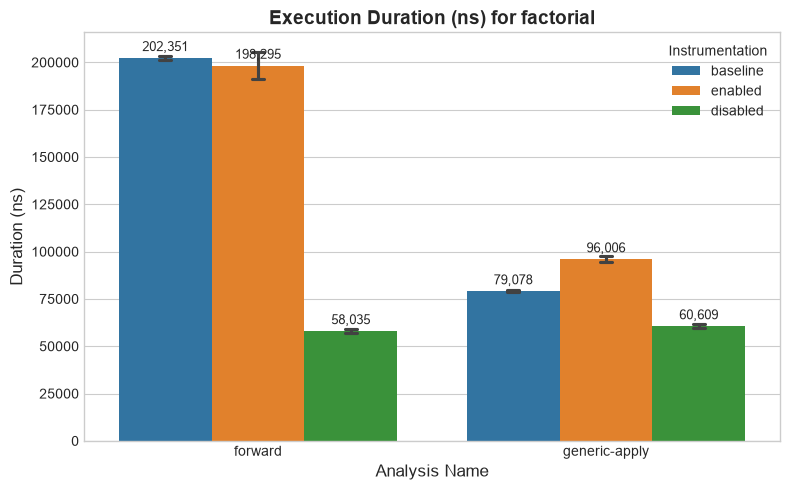

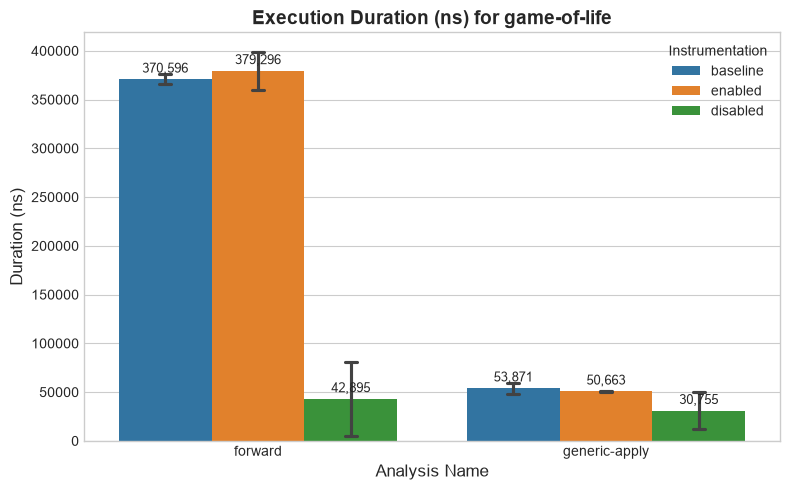

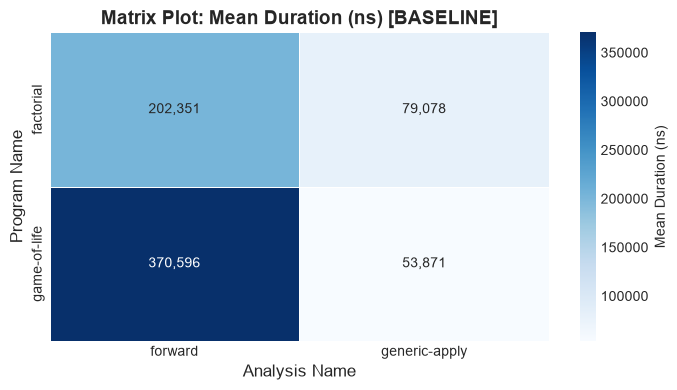

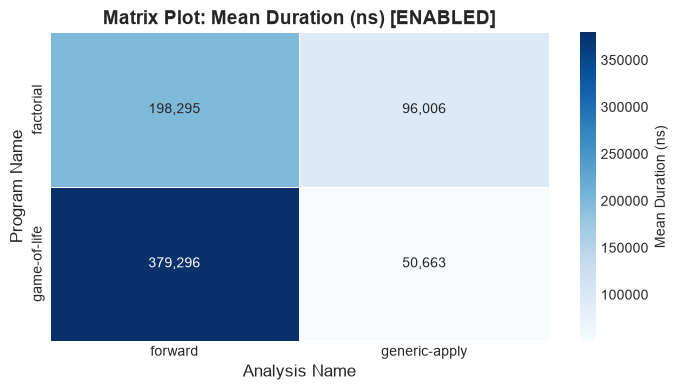

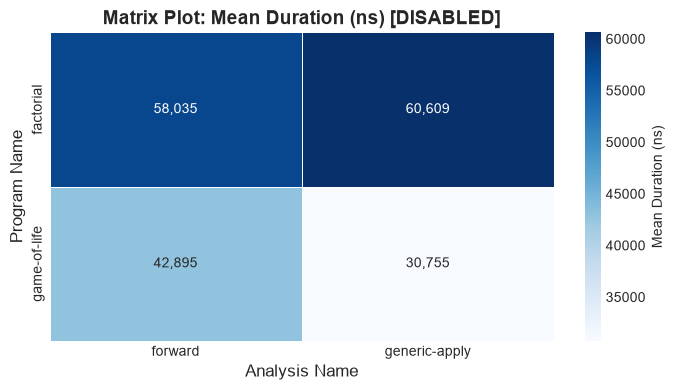

In [39]:
# Compute summary statistics (mean, std, min, max, count) for duration_ns
stats = all_timings.groupby(['program_name', 'analysis_name', 'instrumentation'])['duration_ns'].agg(
    ['count', 'mean', 'std', 'min', 'max']
).reset_index()

print("SUMMARY STATISTICS:")
print(stats.to_string())

# 1. Grouped bar plot for each program
programs = all_timings['program_name'].unique()

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

for prog in programs:
    sub_df = all_timings[all_timings['program_name'] == prog]
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=sub_df,
        x='analysis_name',
        y='duration_ns',
        hue='instrumentation',
        errorbar='sd',
        capsize=0.1
    )
    plt.title(f'Execution Duration (ns) for {prog}', fontsize=14, fontweight='bold')
    plt.xlabel('Analysis Name', fontsize=12)
    plt.ylabel('Duration (ns)', fontsize=12)
    plt.legend(title='Instrumentation')
    
    # Add value labels on bars
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height) and height > 0:
            ax.annotate(f'{height:,.0f}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=9, xytext=(0, 3),
                        textcoords='offset points')
                        
    plt.tight_layout()
    plt.savefig(f'bar_plot_{prog}.png', dpi=300)
    plt.show()

# 2. Matrix plot (heatmap) for each instrumentation state
instrumentations = all_timings['instrumentation'].unique()

for inst in instrumentations:
    sub_df = all_timings[all_timings['instrumentation'] == inst]
    pivot_df = sub_df.pivot_table(index='program_name', columns='analysis_name', values='duration_ns', aggfunc='mean')
    
    plt.figure(figsize=(7, 4))
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=',.0f',
        cmap='Blues',
        cbar_kws={'label': 'Mean Duration (ns)'},
        linewidths=0.5
    )
    plt.title(f'Matrix Plot: Mean Duration (ns) [{inst.upper()}]', fontsize=14, fontweight='bold')
    plt.xlabel('Analysis Name', fontsize=12)
    plt.ylabel('Program Name', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'matrix_{inst}.png', dpi=300)
    plt.show()

overhead

    program_name   analysis_name instrumentation    duration_ns  uninst_baseline  relative_overhead_pct  speedup_factor
0      factorial         forward        baseline  202350.666667     57015.666667             254.903623        3.549036
1      factorial         forward        disabled   58034.666667     57015.666667               1.787228        1.017872
2      factorial         forward         enabled  198295.333333     57015.666667             247.790958        3.477910
3      factorial   generic-apply        baseline   79078.333333     57015.666667              38.695797        1.386958
4      factorial   generic-apply        disabled   60608.666667     57015.666667               6.301777        1.063018
5      factorial   generic-apply         enabled   96006.000000     57015.666667              68.385298        1.683853
6      factorial  uninstrumented  uninstrumented   57015.666667     57015.666667               0.000000        1.000000
7   game-of-life         forward        

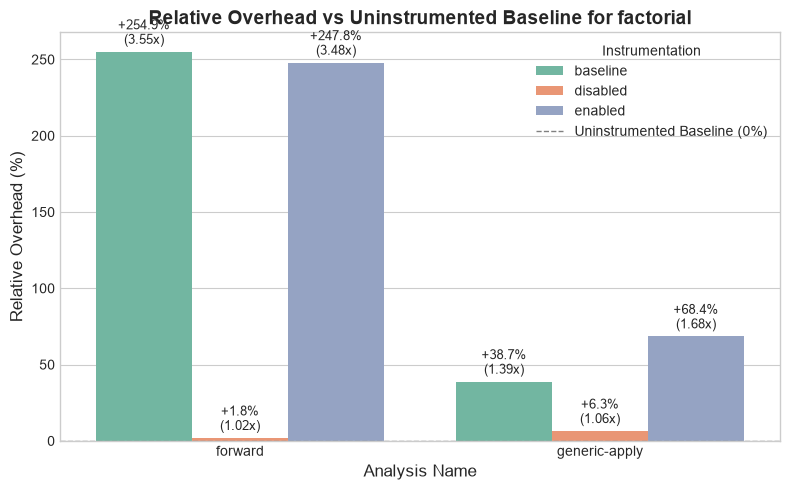

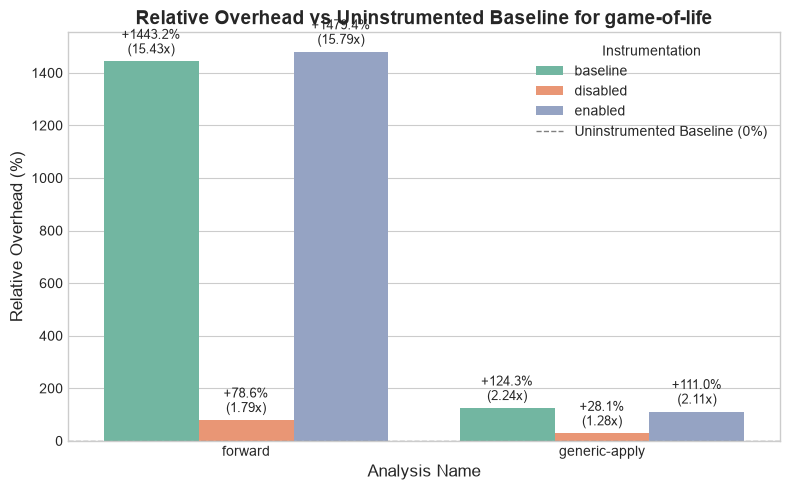

In [40]:
# Compute mean uninstrumented baseline per program
uninst_means = alll_timings[alll_timings['analysis_name'] == 'uninstrumented'].groupby('program_name')['duration_ns'].mean().to_dict()

# Compute mean duration per group
summary = alll_timings.groupby(['program_name', 'analysis_name', 'instrumentation'])['duration_ns'].mean().reset_index()

# Exclude uninstrumented analysis from analysis_name on x-axis if desired, or keep it as 0% reference / baseline.
# Calculating relative overhead (%): (mean_duration - baseline) / baseline * 100
# Alternatively ratio: mean_duration / baseline
summary['uninst_baseline'] = summary['program_name'].map(uninst_means)
summary['relative_overhead_pct'] = ((summary['duration_ns'] - summary['uninst_baseline']) / summary['uninst_baseline']) * 100
summary['speedup_factor'] = summary['duration_ns'] / summary['uninst_baseline']

print(summary.to_string())

# Filter out uninstrumented from analysis_name to focus on analyses (forward, generic-apply)
df_analyses = summary[summary['analysis_name'] != 'uninstrumented'].copy()

programs = df_analyses['program_name'].unique()

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

for prog in programs:
    sub_df = df_analyses[df_analyses['program_name'] == prog]
    
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=sub_df,
        x='analysis_name',
        y='relative_overhead_pct',
        hue='instrumentation',
        palette='Set2'
    )
    
    # Add baseline reference line at 0%
    plt.axhline(0, color='gray', linestyle='--', linewidth=1, label='Uninstrumented Baseline (0%)')
    
    plt.title(f'Relative Overhead vs Uninstrumented Baseline for {prog}', fontsize=14, fontweight='bold')
    plt.xlabel('Analysis Name', fontsize=12)
    plt.ylabel('Relative Overhead (%)', fontsize=12)
    plt.legend(title='Instrumentation')
    
    # Annotate bar values (% overhead and factor)
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height) and height != 0:
            ax.annotate(f'+{height:.1f}%\n({(1 + height/100):.2f}x)',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=9, xytext=(0, 3),
                        textcoords='offset points')
                        
    plt.tight_layout()
    plt.savefig(f'overhead_bar_plot_{prog}.png', dpi=300)
    plt.show()